In [8]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, atan2, sqrt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

In [9]:
#Insert here your seismic source parameters [globalcmt.org]
#2011 Tohoku earthquake
earthquake = {
    'event': '2011 Tohoku earthquake',
    'time': '2011 03 11 05:47:32.8',
    'latitude': 37.52,
    'longitude': 143.05,
    'depth_km': 20,
    'Mw': 9.1,
    'scalar_moment_Nm': 5.31e29,
    'strike_deg': 203,
    'dip_deg': 10,
    'rake_deg': 88
}

In [10]:
# Loading the NEIC earthquake catalog
file_path = 'data/NEIC_Global_1900_2025.csv'
eq_df = pd.read_csv(file_path)

#Converting time and cleaning catalog from NaNs in specified columns
eq_df['time'] = pd.to_datetime(eq_df['time'], errors='coerce').dt.tz_convert('UTC')
eq_df = eq_df.dropna(subset=['time', 'latitude', 'longitude', 'depth', 'mag'])

# Display first few rows to inspect column names
eq_df.head()

C:\Users\seeker\AppData\Local\Temp\ipykernel_8816\2481015680.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  eq_df['time'] = pd.to_datetime(eq_df['time'], errors='coerce').dt.tz_convert('UTC')


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
3,1900-01-31 19:22:00+00:00,48.0,146.0,450.0,7.50,mj,NaN,NaN,NaN,NaN,...,2025-04-26T21:47:57.256Z,Sea of Okhotsk,earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
5,1900-05-11 17:23:00+00:00,38.7,141.1,5.0,7.00,mj,NaN,NaN,NaN,NaN,...,2025-04-26T22:20:13.984Z,"Northern Honshu, Japan",earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
9,1900-10-09 12:28:30+00:00,57.4,-151.0,20.0,7.86,mw,NaN,NaN,NaN,NaN,...,2024-12-31T01:27:41.842Z,"Kodiak Island region, Alaska",earthquake,80.0,NaN,NaN,NaN,reviewed,official,pt
12,1900-11-24 07:57:00+00:00,43.5,148.0,35.0,7.00,ms,NaN,NaN,NaN,NaN,...,2025-04-23T23:45:17.013Z,Kuril Islands,earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
13,1900-12-25 05:09:00+00:00,43.0,146.0,35.0,7.10,mw,NaN,NaN,NaN,NaN,...,2025-04-24T00:20:45.788Z,"Off the coast of Hokkaido, Japan",earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent


In [11]:
#Reading lithospheric plate bounadries for NNR-MORVEL56 model [Argus et al., 2011]
file_path = 'data/All_boundaries'

latitudes = []
longitudes = []

with open(file_path, 'r') as file:
    for line in file:
        if not line.startswith(' '):
            continue  # skip comment lines without leading spaces
        try:
            parts = line.strip().split()
            if len(parts) != 2:
                print(f"Skipping malformed line: {line.strip()}")
                continue
            lat, lon = map(float, parts)
            latitudes.append(lat)
            longitudes.append(lon)
        except Exception as e:
            print(f"Error parsing line '{line.strip()}': {e}")

# Create DataFrame
boundaries_df = pd.DataFrame({
    'latitude': latitudes,
    'longitude': longitudes
})

print(boundaries_df.head())

   latitude  longitude
0   -54.852     -0.438
1   -54.677     -0.039
2   -54.451      0.443
3   -54.832      0.965
4   -54.399      1.695


In [12]:
#Haversine formula for calculating distance between two points on Earth
def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth radius in km
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c  # distance in km

In [13]:
#Afterchocks identification using (Molchan and Dmitrieva, 1991) clustering algorithm
#Filter eq catalog by time and range from epicenter

start_date = pd.to_datetime(earthquake['time']).tz_localize('UTC')
start_date -= relativedelta(days=1)
end_date = start_date + relativedelta(months=2)  #2 months time interval

print(f"Mainshock date: {start_date.date()} -> End date defining the time interval for aftershock identification: {end_date.date()}")

# Filter by time window
df_time = eq_df[(eq_df['time'] >= start_date) & (eq_df['time'] <= end_date)].copy()

# Calculate Haversine distances
df_time['distance_km'] = df_time.apply(
    lambda row: haversine_distance(earthquake['latitude'], earthquake['longitude'], row['latitude'], row['longitude']),
    axis=1
)

# Filter by distance <= 500 km
filtered_df = df_time[df_time['distance_km'] <= 500].copy()

#Deleting events the provide zero distance to avoid log domain error
filtered_df.drop_duplicates(subset=['latitude', 'longitude', 'time'], inplace=True)

import sklearn.metrics.pairwise

def remove_close_spatial_temporal_events(df, distance_km_threshold=0.01, time_minutes_threshold=1):
    coords = df[['latitude', 'longitude']].values
    coords_rad = np.radians(coords)
    distances_km = sklearn.metrics.pairwise.haversine_distances(coords_rad)

    # Compute pairwise time differences in minutes
    time_diffs_minutes = np.abs(np.subtract.outer(df['time'].values, df['time'].values)) / np.timedelta64(1, 'm')

    # Ignore self-comparisons
    np.fill_diagonal(distances_km, np.nan)
    np.fill_diagonal(time_diffs_minutes, np.nan)

    # Find events too close in both space and time
    close_pairs = (distances_km < distance_km_threshold) & (time_diffs_minutes < time_minutes_threshold)

    # Remove duplicates by keeping first occurrence
    to_drop = set()
    for i in range(len(df)):
        if i in to_drop:
            continue
        close_indices = np.where(close_pairs[i])[0]
        for j in close_indices:
            if j > i:
                to_drop.add(j)

    cleaned_df = df.drop(df.index[list(to_drop)]).reset_index(drop=True)
    return cleaned_df, to_drop

cleaned_df, removed_indices = remove_close_spatial_temporal_events(
    df=filtered_df,
    distance_km_threshold=1,         # 1 km
    time_minutes_threshold=10         # 10 minutes
)

print(f"Removed {len(removed_indices)} events.")

cleaned_df.reset_index(drop=True, inplace=True)

print(f"Found {len(cleaned_df)} earthquakes within 2 months and 500 km radius.")

# Creating input file for Smirnov's program (AftIdent)
outname = 'aftmark.cat'
with open(outname, "w") as out:
    for i, row in cleaned_df.iterrows():
        try:
            # Parse datetime string
            dt = row['time']
            dd = f"{dt.day:02d}"
            MM = f"{dt.month:02d}"
            yyyy = f"{dt.year}"
            hh = f"{dt.hour:02d}"
            mm = f"{dt.minute:02d}"
            ss = f"{dt.second:02d}"

            # Format lat, lon, depth, mag
            lat = f"{float(row['latitude']):7.3f}"
            lon = f"{float(row['longitude']):8.3f}"
            depth = f"{float(row['depth']):06.2f}"
            mag = f"{float(row['mag']):05.2f}"

            # Compute energy class
            energy_class = 4.6 + 1.5 * float(row['mag'])
            energy_class_str = f"{energy_class:05.2f}"

            # Identifier
            rec_id = f"{i+1:06d}"

            # Write main line
            out.write(f"{dd}.{MM}.{yyyy} {hh}:{mm}:{ss} {lat} {lon} {depth} {energy_class_str} 0 00004 {rec_id}              !\n")
            
        except Exception as e:
            print(f"Skipping row {i} due to error: {e}")

Mainshock date: 2011-03-10 -> End date defining the time interval for aftershock identification: 2011-05-10
Removed 1057 events.
Found 1324 earthquakes within 2 months and 500 km radius.


In [14]:
# Reading result file from Smirnov's program output

resultname = 'data/aftmark_res.cat'

# Load catalog
result_df = pd.read_csv(resultname, sep='\s+', names = ['date', 'time', 'latitude', 'longitude', 'depth', 'energy_class', 'key', 'dummy_code1', 'id', \
           'dummy_code2', 'group_id', 'comm'], dtype = {'date': str, 'time': str, 'lat': np.float64, 'lon': np.float64, 'depth': np.float64, \
           'energy_class': np.float64, 'key': np.int64, 'dummy_code1': np.int64, 'id': np.int64, 'dummy_code2': str, 'group_id': str, 'comm': str})

# Convert time to datetime datetime in catalog
result_df['full_time'] = pd.to_datetime(result_df['date'] + ' ' + result_df['time'], errors='coerce', utc=True, format = '%d.%m.%Y %H:%M:%S')

# Convert mainshock time
mainshock_time = pd.to_datetime(earthquake['time'], utc=True)

# Compute absolute time difference in seconds
result_df['time_diff_sec'] = np.abs((result_df['full_time'] - mainshock_time).dt.total_seconds())

# Find the closest mainshock candidate within 1 second
mainshock_row = result_df[(result_df['time_diff_sec'] <= 100) & (result_df['key'] == 2)]

if mainshock_row.empty:
    print(f"Mainshock {mainshock_time} not found.")
    aftershocks_ai = pd.DataFrame(columns=['time', 'latitude', 'longitude', 'depth', 'mag'])
else:
    mainshock_group_value = float(mainshock_row['id'])
    result_df['group_id'] = result_df['group_id'].astype(float)
    aftershocks_ai = result_df[(result_df['key'] == 1) & (result_df['group_id'] == mainshock_group_value)]

    print(f"Found {len(aftershocks_ai)} aftershocks linked to mainshock.")

Found 1111 aftershocks linked to mainshock.


C:\Users\seeker\AppData\Local\Temp\ipykernel_8816\4292951312.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mainshock_group_value = float(mainshock_row['id'])


In [15]:
#Gardner-Knopoff Windowing (empirical time and distance windows based on the mainshock's magnitude)
#Gardner & Knopoff (1974)

def gardner_knopoff_windows(mag):
    time_window_days = 10 ** (0.032 * mag + 2.7389) / (60*60*24)  # seconds to days
    distance_km = 10 ** (0.1238 * mag + 0.983)  # empirical distance in km
    return time_window_days, distance_km

def select_gk_aftershocks(eq_df, mainshock_time, mainshock_lat, mainshock_lon, mainshock_mag):
    mainshock_time = pd.to_datetime(mainshock_time).tz_localize('UTC')
    time_window, dist_window = gardner_knopoff_windows(mainshock_mag)

    temp_df = eq_df.copy()
    temp_df['days_since_main'] = (temp_df['time'] - mainshock_time).dt.days

    # Calculate Haversine distances
    temp_df['distance_km'] = temp_df.apply(
        lambda row: haversine_distance(mainshock_lat, mainshock_lon, row['latitude'], row['longitude']),
        axis=1
    )

    aftershocks = temp_df[
        (temp_df['days_since_main'] >= 0) &
        (temp_df['days_since_main'] <= time_window) &
        (temp_df['distance_km'] <= dist_window)
    ]
    return aftershocks

aftershocks_gk = select_gk_aftershocks(eq_df, mainshock_time=earthquake['time'], mainshock_lat=earthquake['latitude'], mainshock_lon=earthquake['longitude'], mainshock_mag=earthquake['Mw'])
print(f"Found {len(aftershocks_gk)} aftershocks")

Found 226 aftershocks


In [16]:
#Reasenberg Declustering (Reasenberg, 1985)

def reasenberg_declustering_full(eq_df,
    interaction_days_base=30,  # base time window in days
    interaction_distance_base=10,  # base distance window in km
    mag_ref=4.0,
    alpha=0.5,  # time window scaling per magnitude
    beta=0.5):  # distance window scaling per magnitude

    eq_df = eq_df.copy()
    eq_df = eq_df.sort_values('time').reset_index(drop=True)
    eq_df['cluster_id'] = -1

    cluster_counter = 0

    for i, mainshock in eq_df.iterrows():
        if eq_df.loc[i, 'cluster_id'] != -1:
            continue  # already assigned

        mag = mainshock['mag']
        t0 = mainshock['time']
        lat0, lon0 = mainshock['latitude'], mainshock['longitude']

        # Dynamic interaction window scaling with magnitude
        interaction_days = interaction_days_base * 10 ** (alpha * (mag - mag_ref))
        interaction_distance = interaction_distance_base * 10 ** (beta * (mag - mag_ref))

        # Time window mask
        time_window = (eq_df['time'] >= t0) & (eq_df['time'] <= t0 + timedelta(days=interaction_days))
        candidates = eq_df.loc[time_window]

        # Distance calculation
        distances = candidates.apply(lambda row: haversine_distance(lat0, lon0, row['latitude'], row['longitude']), axis=1)

        # Find candidates within space window
        spatial_mask = distances <= interaction_distance

        cluster_indices = candidates.index[spatial_mask]

        if len(cluster_indices) > 0:
            eq_df.loc[cluster_indices, 'cluster_id'] = cluster_counter
            cluster_counter += 1

    return eq_df

declustered_df = reasenberg_declustering_full(filtered_df)

#Declustered catalog
background_df = declustered_df[declustered_df['cluster_id'] == -1]

#Aftershock clusters
#aftershocks_reas = declustered_df[declustered_df['cluster_id'] != -1]   #All clusters
aftershocks_reas = declustered_df[declustered_df['cluster_id'] == 2]   #Only 3 cluster
print(f"Found {len(aftershocks_reas)} aftershocks")

Found 2371 aftershocks


Found 1870 aftershocks


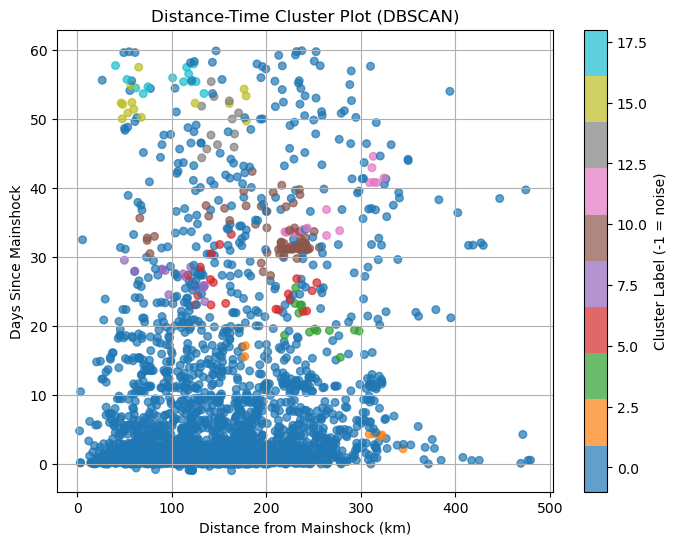

In [17]:
#DBSCAN Clustering for aftershocks identification

def dbscan_aftershocks(eq_df, mainshock_time, eps=0.5, min_samples=3):
    mainshock_time = pd.to_datetime(mainshock_time).tz_localize('UTC')
    eq_df['days_since_main'] = (eq_df['time'] - mainshock_time).dt.total_seconds() / (24 * 3600)
    
    features = eq_df[['latitude', 'longitude', 'days_since_main']].values

    #Standardizing feature vector
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    eq_df['dbscan_cluster'] = db.fit_predict(X_scaled)
    return eq_df

dbscan_df = dbscan_aftershocks(filtered_df, earthquake['time'], eps=0.3, min_samples=5)
#aftershocks_dbscan = dbscan_df[dbscan_df['dbscan_cluster'] != -1]   #All clusters
aftershocks_dbscan = dbscan_df[dbscan_df['dbscan_cluster'] == 0 ]   #only first cluster

print(f"Found {len(aftershocks_dbscan)} aftershocks")

def plot_distance_time_clusters(eq_df):
    eq_plot_df = eq_df.copy()

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(eq_plot_df['distance_km'], eq_plot_df['days_since_main'], 
                          c=eq_plot_df['dbscan_cluster'], cmap='tab10', s=30, alpha=0.7)

    plt.colorbar(scatter, label='Cluster Label (-1 = noise)')
    plt.xlabel("Distance from Mainshock (km)")
    plt.ylabel("Days Since Mainshock")
    plt.title("Distance-Time Cluster Plot (DBSCAN)")
    plt.grid(True)
    plt.show()

plot_distance_time_clusters(dbscan_df)

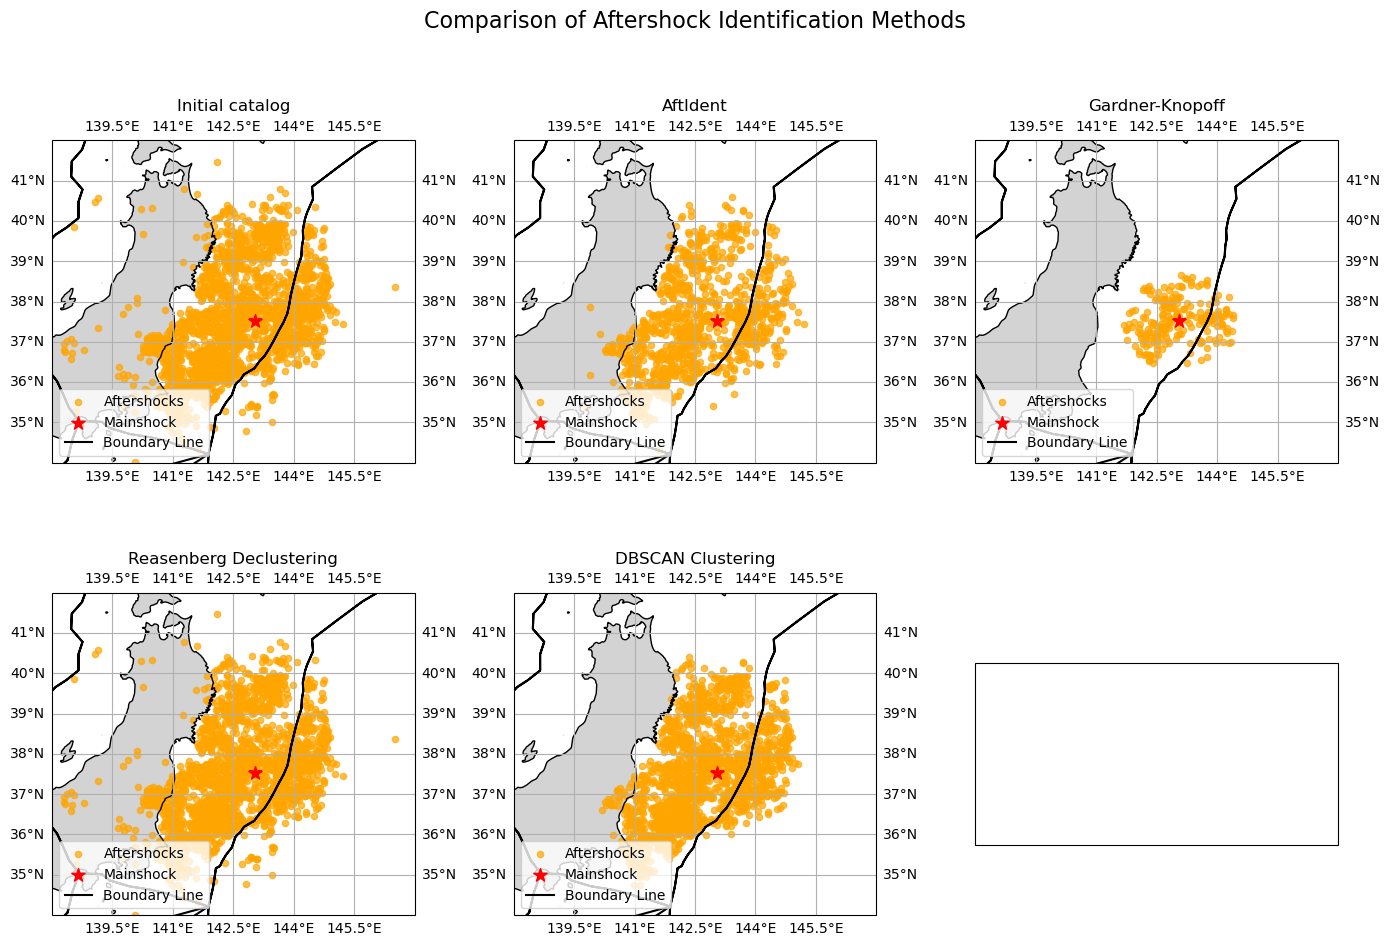

In [18]:
#Plotting aftershocks

def plot_aftershock_methods_map(full_df, ai_df, gk_df, reas_df, dbscan_df, mainshock_lat, mainshock_lon):
    fig, axs = plt.subplots(2, 3, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    methods = [
        ("Initial catalog", full_df, axs[0, 0]),
        ("AftIdent", ai_df, axs[0, 1]),
        ("Gardner-Knopoff", gk_df, axs[0, 2]),
        ("Reasenberg Declustering", reas_df, axs[1, 0]),
        ("DBSCAN Clustering", dbscan_df, axs[1, 1])
    ]

    for title, df, ax in methods:
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.gridlines(draw_labels=True)

        # Plot aftershocks
        ax.scatter(df['longitude'], df['latitude'], color='orange', s=20, label='Aftershocks', alpha=0.7)

        # Plot mainshock
        ax.scatter(mainshock_lon, mainshock_lat, color='red', marker='*', s=100, label='Mainshock', zorder=5)

        # Boundary line
        ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

        # Dynamic extent with padding
        #min_lon = min(df['longitude'].min(), mainshock_lon) - 0.5
        #max_lon = max(df['longitude'].max(), mainshock_lon) + 0.5
        #min_lat = min(df['latitude'].min(), mainshock_lat) - 0.5
        #max_lat = max(df['latitude'].max(), mainshock_lat) + 0.5
        min_lon = 138
        max_lon = 147
        min_lat = 34
        max_lat = 42
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

        ax.set_title(title)
        ax.legend(loc='lower left')

    plt.suptitle("Comparison of Aftershock Identification Methods", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_aftershock_methods_map(
    full_df = filtered_df,
    ai_df=aftershocks_ai,
    gk_df=aftershocks_gk,
    reas_df=aftershocks_reas,
    dbscan_df=aftershocks_dbscan,
    mainshock_lat=earthquake['latitude'],
    mainshock_lon=earthquake['longitude']
)